In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation Parameters
STEPS = 100
GRASS_REGROWTH = 60


GRASS_MAX = 200
HUNT_SUCCESS_RATE = 0.5

# Initial Populations
grass = [100]
rabbits = [20]   # Species A
snails = [30]    # Species B
foxes = [5]      # Species C


In [4]:
for t in range(STEPS):
    curr_grass = grass[-1] + GRASS_REGROWTH
    if curr_grass > GRASS_MAX: curr_grass = GRASS_MAX
    
    curr_rabbits = rabbits[-1]
    curr_snails = snails[-1]
    curr_foxes = foxes[-1]
    
    # 1. Predation Phase: Foxes hunt Rabbits
    # Each fox attempts to eat one rabbit
    successful_hunts = 0
    for _ in range(curr_foxes):
        if curr_rabbits > 5 and np.random.random() < HUNT_SUCCESS_RATE:
            successful_hunts += 1
            curr_rabbits -= 1
            
    # Fox survival/reproduction
    new_foxes = successful_hunts * 2 # Ate = survive + reproduce
    
    # 2. Grazing Phase: Snails eat first (Efficiency advantage)
    snails_who_ate = min(curr_snails, int(curr_grass / 0.5))
    curr_grass -= (snails_who_ate * 0.5)
    new_snails = snails_who_ate * 2
    
    # 3. Grazing Phase: Rabbits eat remaining grass
    rabbits_who_ate = min(curr_rabbits, int(curr_grass))
    curr_grass -= rabbits_who_ate
    new_rabbits = rabbits_who_ate * 2
    
    # Append results (Keeping populations non-negative)
    grass.append(curr_grass)
    rabbits.append(max(0, new_rabbits))
    snails.append(max(0, new_snails))
    foxes.append(max(0, new_foxes))


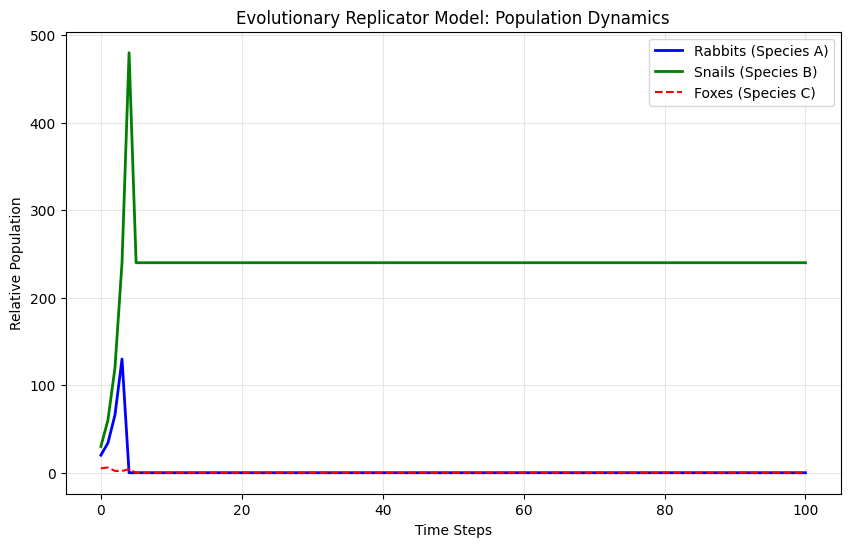

In [5]:
# Plotting the Results
plt.figure(figsize=(10, 6))
plt.plot(rabbits, label='Rabbits (Species A)', color='blue', linewidth=2)
plt.plot(snails, label='Snails (Species B)', color='green', linewidth=2)
plt.plot(foxes, label='Foxes (Species C)', color='red', linestyle='--')
plt.title('Evolutionary Replicator Model: Population Dynamics')
plt.xlabel('Time Steps')
plt.ylabel('Relative Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()